# Data Exploration & Preprocessing
## Diabetes Severity Classification Project

Purpose:
- Load raw Kaggle diabetes dataset
- Perform data inspection and cleaning
- Visualize key statistics
- Zero-as-missing handling (not NaN)
- Save cleaned dataset for reuse in ML pipeline

This notebook is designed to be converted into a Python script
and reused in main.py for reproducibility.


📁 Dataset Choice (Kaggle – real-world, CV-safe)

We use the Pima Indians Diabetes Dataset (classic healthcare dataset, widely accepted).

🔗 Kaggle link

👉 Pima Indians Diabetes Database
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Target column

Outcome

1 → Diabetes

0 → No Diabetes

⚠️ This dataset has known data quality issues (zeros where medically impossible), which is PERFECT for showing data cleaning skills.

<!-- 1 – Imports & configuration -->
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Better display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [30]:
RAW_DATA_PATH = "../data/diabetes_raw.csv"
PROCESSED_DATA_PATH = "../data/diabetes_processed.csv"
df = pd.read_csv(RAW_DATA_PATH)

RAW_DATA_PATH = "../data/diabetes_raw.csv"
PROCESSED_DATA_PATH = "../data/diabetes_processed.csv"
try:
    df = pd.read_csv(RAW_DATA_PATH)
    print("Dataset loaded successfully.")
    df.head()
except FileNotFoundError:
    print(f"Error: File not found at {RAW_DATA_PATH}")
df.head()


Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
missing_values = df.isnull().sum()

print("Missing values per column:\n")
missing_values



Missing values per column:



Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
invalid_zero_columns = [
    col for col in df.columns
    if col != TARGET_COLUMN
]

(df[invalid_zero_columns] == 0).sum()


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [32]:
df_cleaned = df.copy()

for col in invalid_zero_columns:
    df_cleaned[col] = df_cleaned[col].replace(0, np.nan)

df_cleaned.isnull().sum()


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

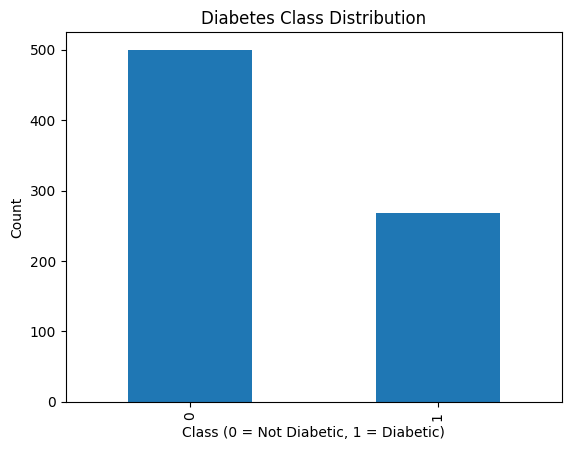

In [17]:
class_counts = df_cleaned[TARGET_COLUMN].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.title("Diabetes Class Distribution")
plt.xlabel("Class (0 = Not Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()


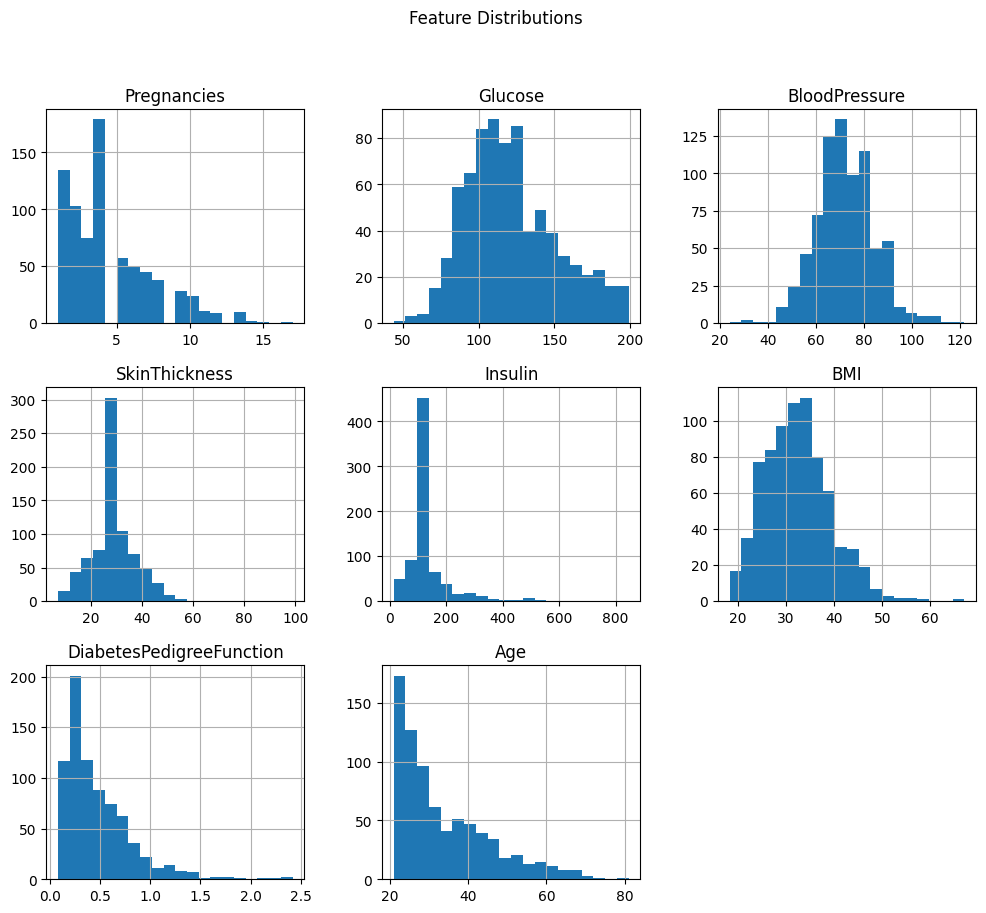

In [18]:
df_cleaned.drop(columns=[TARGET_COLUMN]).hist(
    figsize=(12, 10),
    bins=20
)
plt.suptitle("Feature Distributions")
plt.show()


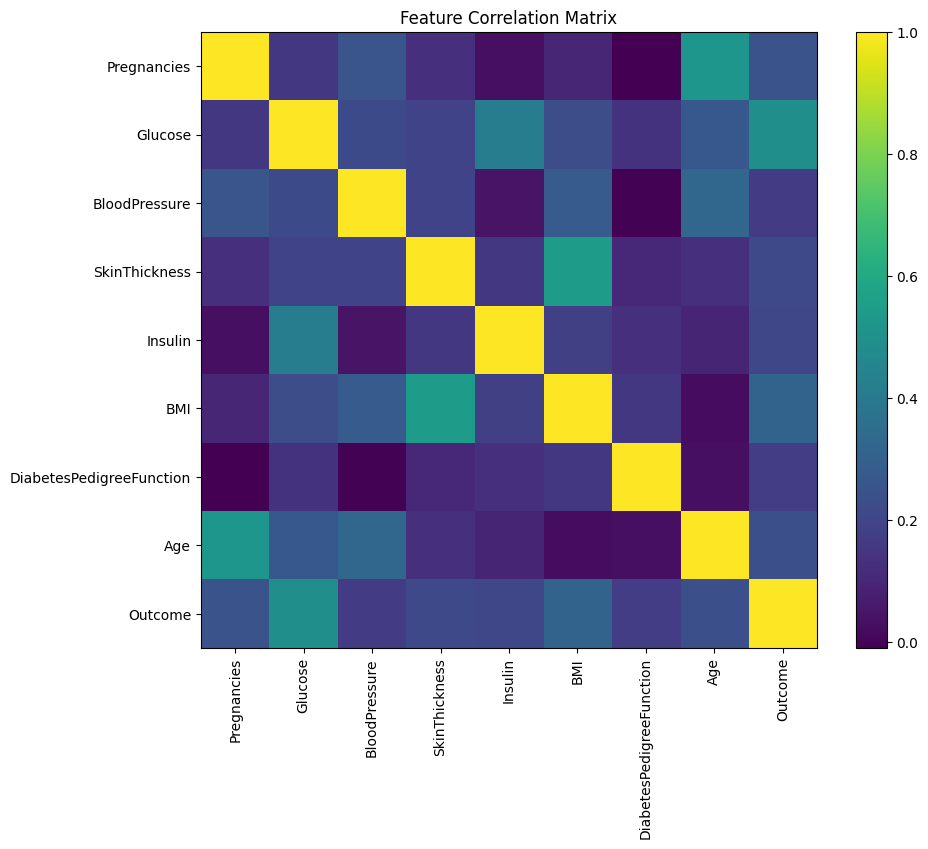

In [19]:
correlation_matrix = df_cleaned.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.show()


In [21]:
os.makedirs(os.path.dirname(PROCESSED_DATA_PATH), exist_ok=True)

df_cleaned.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Processed dataset saved to {PROCESSED_DATA_PATH}")
print("Data exploration and preprocessing completed successfully.")
print("Processed data shape:", df_cleaned.shape)



Processed dataset saved to ../data/diabetes_processed.csv
Data exploration and preprocessing completed successfully.
Processed data shape: (768, 9)
